In [34]:
# Import libraries
from qiskit import QuantumCircuit, transpile

# Quantum Circuit
from qiskit.primitives import Sampler

# Run with simulators
from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Visualzation
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector

# Regular Imports
import numpy as np
from numpy import pi

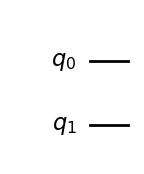

In [35]:
n = 2
grover_2q11= QuantumCircuit(n)

grover_2q11.draw("mpl")

In [36]:
# Initialize the quantum state
def Initialize_S(qc, qubits):
    for q in range(qubits):
        qc.h(q)
    return qc

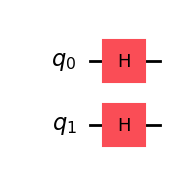

In [37]:
grover_2q11 = Initialize_S(grover_2q11, n)

grover_2q11.draw("mpl")

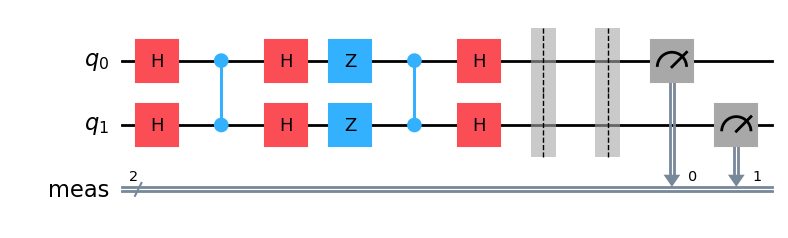

In [38]:
# Apply the Oracle for |w> = |11>

grover_2q11.cz(0, 1)



# Apply the diffusion operator (U_s)
grover_2q11.h([0, 1])
grover_2q11.z([0, 1])
grover_2q11.cz(0, 1)
grover_2q11.h([0, 1])

grover_2q11.barrier()
grover_2q11.measure_all()


grover_2q11.draw("mpl")

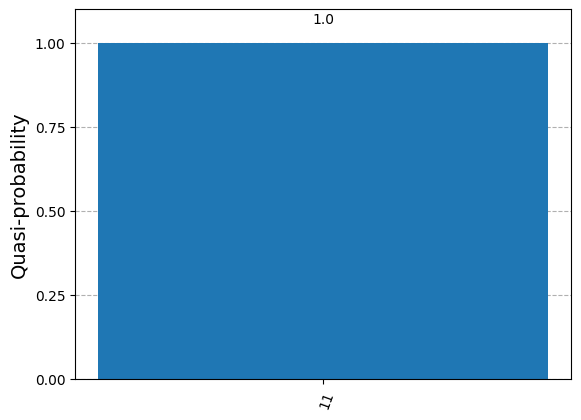

In [39]:
sampler = AerSampler()
job_sim = sampler.run([grover_2q11], shots=4096)

quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()

plot_histogram(quasi_dists)